# Plots

Figures only. Setup is copied from `try.ipynb` (cells 1 and 9) so this notebook runs on its own without the SHAP cells.
Run the two setup cells once, then work in the sections below.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import streamflow_model as S

# load the released (bugged) model and build standardized inputs + target (try.ipynb cell 1)
weights = S.load_weights("model/streamflow_model_bug.npz")
feats = S.build_features("data/train.csv", "model/feature_scaler.json")
X, truth = feats["X"], feats["truth"]
print(f"{len(X)} usable examples, {X.shape[1]} features each")

18685 usable examples, 77 features each


In [2]:
# run the model, and grab hidden activations (try.ipynb cell 9)
pred, acts = S.forward(weights, X, return_hidden=True) #acts: activation; pred: predicted streamflow
print("layers with activations:", list(acts.keys()))
print(pred)

dates = feats["datetime"]   # lines up with X row for row
rain = feats["rain"]        # hourly rainfall, mm
print(pred.shape, truth.shape, rain.shape, len(dates))   # all should have 18685 rows
print(dates[0], "to", dates[-1])

layers with activations: ['fc1', 'fc2', 'fc3', 'fc4', 'fc5', 'fc6']
[0.03030184 0.0260518  0.0219172  ... 0.00782154 0.00782154 0.00782154]
(18685,) (18685,) (18685,) 18685
2023-10-29T11:00:00.000000 to 2025-12-16T18:00:00.000000


In [3]:
print(sum(feats["truth"]))


434.9121


## 1. Monthly streamflow (observed vs predicted) with monthly rainfall

**Goal.** The "pdf" version of the organizers' cumulative phantom-water plot.

- x-axis: the whole public period, start date to end date (2023-10-29 to 2025-12-16, about 2 years 2 months; the rows after that are the held-out set)
- left y-axis: monthly streamflow, observed and predicted, mm per month
- right y-axis: monthly rainfall, mm per month

No clean-model data, so only observed and bugged.

Units: rows are hourly and flow is in mm/hr, so summing over a month gives mm per month directly.

### 1a. One hourly DataFrame

- `pd.DataFrame({...}, index=pd.DatetimeIndex(dates))` with three columns: observed, predicted, rain
- if `pred.shape` printed above is `(18685, 1)`, flatten it with `.ravel()` first

In [4]:
plot_df = pd.DataFrame({"pred": pred.astype(np.float64), "truth": truth.astype(np.float64), "rain": rain.astype(np.float64)}, index=pd.DatetimeIndex(dates)) #@claude why do the pd version?
plot_df

,pred,truth,rain
2023-10-29 11:00:00,0.030302,0.025719,0.0
2023-10-29 12:00:00,0.026052,0.025616,0.0
2023-10-29 13:00:00,0.021917,0.025514,0.0
2023-10-29 14:00:00,0.019328,0.025412,0.0
2023-10-29 15:00:00,0.019153,0.025310,0.0
...,...,...,...
2025-12-16 14:00:00,0.007822,0.000410,0.0
2025-12-16 15:00:00,0.007822,0.000409,0.0
2025-12-16 16:00:00,0.007822,0.000407,0.0
2025-12-16 17:00:00,0.007822,0.000405,0.0


### 1b. Hourly to monthly

- `.resample("MS").sum()` gives monthly totals, each row labeled with the first day of its month (about 27 rows)
- also look at `.resample("MS").count()`: the first month (starts Oct 29) and the last (ends Dec 16) are partial, so their sums look too small. Drop them or note it in the caption.
- sanity check: the monthly observed column summed should equal `truth.sum()`

In [5]:
sample = plot_df.resample("MS")
monthly = sample.sum() #他妈的这玩意儿我打死都想不到啊.......这他妈的还有这样的function？？？我还以为得让我写loop呢...... 
# "MS" means "Month Start" (the first day of the month). Other options include "M" for month end, "W" for week, "D" for day, etc. See https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#dateoffset-objects for more details.
# sample.count()
print(monthly["truth"].sum()) 
print(truth.sum())
monthly["truth"].sum() == truth.sum() #ceaveat: use == to compare float is not a good choice

np.isclose(monthly["truth"].sum(), plot_df["truth"].sum())

434.911063253312
434.91104


np.True_

In [6]:
monthly

,pred,truth,rain
2023-10-01,0.787713,1.401091,2.030000
2023-11-01,6.137843,5.847640,4.030000
2023-12-01,8.826154,4.748764,37.820000
2024-01-01,6.544470,4.995189,10.120000
2024-02-01,6.586654,1.637681,1.270000
2024-03-01,11.442424,2.438206,31.490000
2024-04-01,27.205369,9.999262,94.920000
2024-05-01,40.574292,37.127189,163.269999
2024-06-01,35.137110,39.670553,107.879999
2024-07-01,36.222291,47.283844,116.800000


### 1c. The figure, two y-axes

- `fig, ax = plt.subplots(figsize=(12, 5))` is the left axis (streamflow)
- `ax2 = ax.twinx()` is the right axis (rain), sharing the x-axis
- streamflow: two `ax.plot(monthly.index, ..., marker="o")` calls
- rain: `ax2.bar(..., width=20, alpha=0.3)`. On a datetime axis bar `width` is in **days**; the default 0.8 draws invisible slivers.
- `ax.set_ylabel(...)`, `ax2.set_ylabel(...)` with units
- optional hydrology convention: `ax2.invert_yaxis()` hangs the rain bars from the top; then raise the limit with `ax2.set_ylim(...)` so they only fill the upper third

Polish:

- legend: each axis has its own entries. Get both with `ax.get_legend_handles_labels()` and `ax2.get_legend_handles_labels()`, add the lists, pass to one `ax.legend(handles, labels)`
- date ticks: `ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))`, `ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))`, `fig.autofmt_xdate()`
- save: `plt.savefig("figures/monthly_flow_rain.png", dpi=200, bbox_inches="tight")`

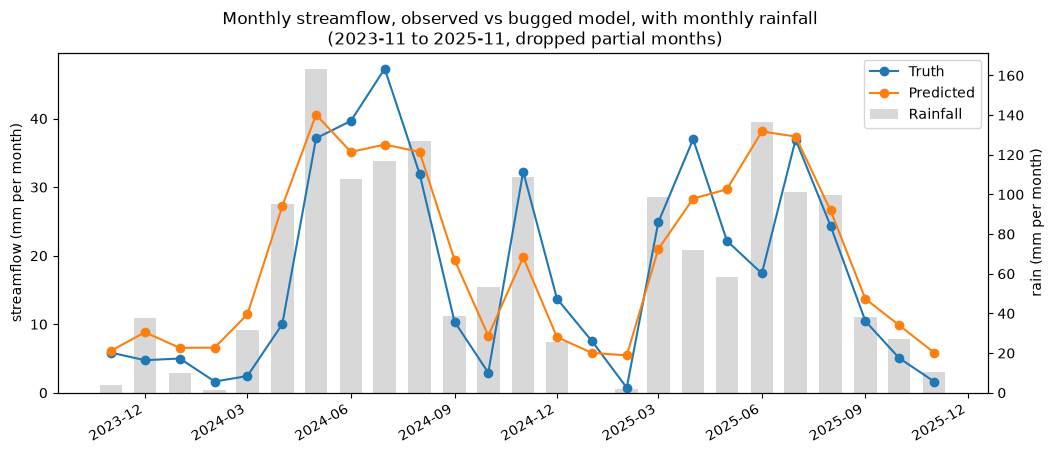

In [7]:
full = monthly.iloc[1:-1] #drop the two partial months: 2023-10 has only 61 hours, 2025-12 only 379

fig, ax = plt.subplots(figsize=(12, 5))
ax2 = ax.twinx() #2nd axis
ax.plot(full.index, full["truth"], marker="o", label="Truth") #transparency is alpha
ax.plot(full.index, full["pred"], marker="o", label="Predicted")
ax2.bar(full.index, full["rain"], width=20, alpha = 0.3, color="grey", label="Rainfall")
ax.set_ylabel("streamflow (mm per month)")
ax2.set_ylabel("rain (mm per month)")
ax.set_title("Monthly streamflow, observed vs bugged model, with monthly rainfall \n (2023-11 to 2025-11, dropped partial months)")

ax.set_ylim(bottom=0) #both y axes start at 0, so lines and bars share a baseline
#twinx draws ax2 on top of ax, so the bars cover the line markers. Put ax in front, and make its background transparent so it doesn't hide the bars
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)

# ax.legend()
# ax2.legend()

h1, l1= ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()
plt.savefig("figures/monthly_flow_rain.png", dpi=200, bbox_inches="tight")

In [13]:
print(pred.min())

print("1, 5, 25, and 50th percentiles of predicted and truth streamflow (mm per hour):")
print("predicted:" + str(np.percentile(pred, [1, 5, 25, 50])))
print("truth:" + str(np.percentile(truth, [1, 5, 25, 50])))

0.007821538
1, 5, 25, and 50th percentiles of predicted and truth streamflow (mm per hour):
predicted:[0.00782154 0.00782154 0.00782179 0.01878721]
truth:[0.00038086 0.00103414 0.00417874 0.01390736]


### Weekly bin

### Empirical CDF



**Goal.** Compare the distribution of hourly flow, predicted vs observed. For each flow value x: what fraction of all hours had a flow of x or less?

- x-axis: hourly streamflow (mm/hr), **log scale**
- y-axis: fraction of hours ≤ x, from 0 to 1
- two curves on one axis: truth and pred
- data: the **hourly** columns `plot_df["truth"]` and `plot_df["pred"]`, not `monthly`

**By hand (do this once, to see how the curve is built)**

1. `np.sort(arr)` gives the x coordinates.
2. After sorting, the 1st value has 1 of n hours at or below it, the 2nd has 2 of n, the last has n of n. So y is `np.arange(1, n + 1) / n` with `n = len(arr)`.
3. `ax.plot(x_sorted, y, label=...)`, once for truth and once for pred. (`ax.step(..., where="post")` is the strictly correct staircase; with 18,685 points it looks the same.)

**One-call version.** `ax.ecdf(arr, label=...)` (matplotlib ≥ 3.8, the venv has 3.11). Draw it on top of the by-hand curve as a check. They should overlap exactly.

**Settings that matter**

- `ax.set_xscale("log")`. Essential. Flow spans 0.0002 to about 0.5 mm/hr; on a linear axis everything below 0.01 is squeezed against the left edge, which is where the interesting part is.
- `ax.set_xlabel("hourly streamflow (mm/hr)")`, `ax.set_ylabel("fraction of hours ≤ x")`
- `ax.grid(True, which="both", alpha=0.3)`. Minor gridlines make values readable on a log axis.
- optional: `ax.axvline(pred.min(), ls="--", color="grey", label="model floor")`
- no twin axis here, so a plain `ax.legend()` works
- save: `plt.savefig("figures/ecdf_hourly_flow.png", dpi=200, bbox_inches="tight")`

**How to read it**

- Pick an x, go up to the curve, read y. "At x = 0.005 the truth curve is at 0.30" means 30% of hours had a real flow of 0.005 mm/hr or less.
- Truth should be a smooth S-curve starting near 0.0002.
- Pred should be flat at 0 until x = 0.0078, jump straight up to about 0.26, then curve upward. That vertical wall is the floor: the 26% of hours sitting on one value. (Matches the percentiles printed above: the 1st, 5th and 25th percentiles of pred are all 0.00782.)
- Where the pred curve is to the **right** of the truth curve at the same height, the model says more water than reality at that rank. If the two curves merge at higher flows, the model's distribution is fine apart from the floor.

**Caveat for the caption.** An ECDF compares two distributions, not hour-by-hour pairs. It shows the model never predicts low values; it does not show *which* hours are wrong. The monthly and weekly plots cover the timing.

In [31]:
#get data
s_pred = np.sort(plot_df["pred"])
s_truth = np.sort(plot_df["truth"])

assert len(s_pred) == len(s_truth), "pred and truth must have same length"

#build fraction
n = len(s_pred)
y = np.arange(1, n + 1) / n #get the cumulative fraction, full is 1 so normalized by n
    #arange means generate a list of number from start to stop. Return evenly spaced values within a given interval.

In [65]:
s_truth

array([1.80832998e-04, 1.81559997e-04, 1.82289004e-04, ...,
       5.45369148e-01, 5.75857460e-01, 5.89342594e-01], shape=(18685,))

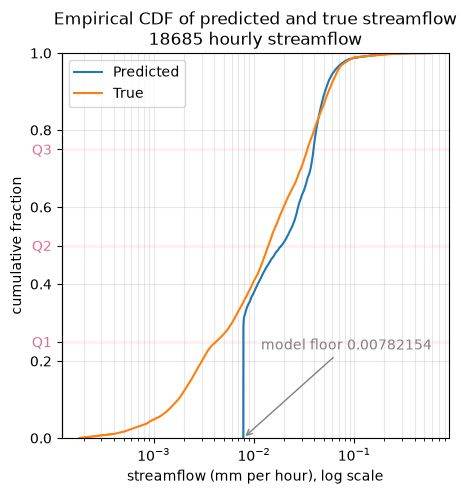

In [111]:
#plot
fig1, ax1 = plt.subplots(figsize=(5, 5))
ax1.ecdf(s_pred, label="Predicted")
ax1.ecdf(s_truth, label="True")
ax1.set_xscale("log") #this is log, not ln!
ax1.set_xlabel("streamflow (mm per hour), log scale")
ax1.set_ylabel("cumulative fraction")
ax1.set_title(f"Empirical CDF of predicted and true streamflow\n{len(s_pred)} hourly streamflow")

ax1.grid(True, which="both", alpha=0.3) 
# ax1.axvline(pred.min(), ls="--", color="grey", label="model floor 0.0078")
ax1.annotate(f"model floor {pred.min():.8f}", xy=(pred.min(), 0), xytext=(pred.min()*1.5, 0.23), 
             arrowprops=dict(arrowstyle="->", color="grey"), color="grey")
for q in [0.25, 0.5, 0.75]:
    ax1.axhline(q, ls="-", lw=2, color="pink", alpha=0.25, zorder=0)
sec = ax1.secondary_yaxis("left")
sec.set_yticks([0.25, 0.5, 0.75], labels=["Q1", "Q2", "Q3"], color="palevioletred", zorder=0)
ax1.legend() #this need to be called after all the label setting.
plt.savefig("figures/ecdf_hourly_flow.png", dpi=200, bbox_inches="tight")

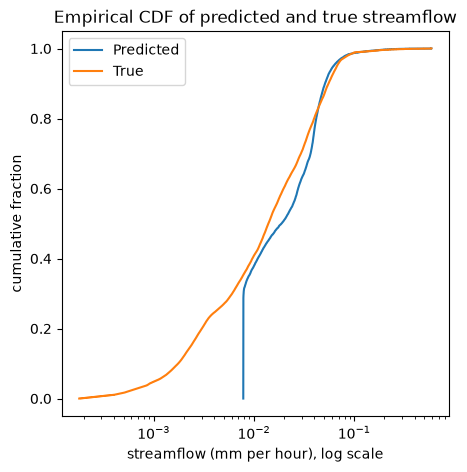

In [ ]:
#plot use plot, just for checking purpose.
fig2, ax2 = plt.subplots(figsize=(5, 5))
ax2.step(s_pred, y, label="Predicted", where="post") #draw the ecdf step shape
ax2.step(s_truth, y, label="True", where="post")
ax2.set_xscale("log") #this is log, not ln!
ax2.set_xlabel("streamflow (mm per hour), log scale")
ax2.set_ylabel("cumulative fraction")
ax2.set_title("Empirical CDF of predicted and true streamflow")
ax2.legend()

#### **Worked example: why the fractions are just 1/n, 2/n, ..., n/n**



Five hours of flow, already sorted small to large:

```
sorted flow:   0.2   0.5   0.5   0.9   3.0
position:      1st   2nd   3rd   4th   5th
```

For each value: what fraction of all hours had a flow this small or smaller?

| Value | Hours at or below it | Fraction (n = 5) |
|---|---|---|
| 0.2 | 1 (itself) | 1/5 = 0.2 |
| 0.5 | 2 | 2/5 = 0.4 |
| 0.5 | 3 | 3/5 = 0.6 |
| 0.9 | 4 | 4/5 = 0.8 |
| 3.0 | 5 (all of them) | 5/5 = 1.0 |

Once the list is sorted, "how many hours are at or below this value" is just **its position in the list**. The 4th smallest value has exactly 4 values at or below it, because sorting put them there. Nothing needs counting. The fractions are always 1/n, 2/n, ..., n/n, whatever the data is.

`np.arange(1, n + 1) / n` builds exactly that:

- `np.arange(1, n + 1)` gives `[1, 2, 3, 4, 5]`, the positions. The `+ 1` is because `arange` stops *before* its end value, like Java's `i < end`. It is the vectorized version of `for i in range(1, n + 1): y.append(i / n)`.
- `/ n` divides every element by 5: `[0.2, 0.4, 0.6, 0.8, 1.0]`.

So x comes from the data (sorted flows) and y depends only on n. Truth and pred have the same n, so one `y` array serves both curves.

**Repeated values make a vertical jump.** The two 0.5s get y = 0.4 and y = 0.6 at the same x, so the curve goes straight up there. The wall in the real plot is the same thing with thousands of repeats: about 4,800 of the 18,685 sorted `pred` values are 0.00782, they take positions 1 to about 4,800, so y runs from 1/18685 to about 0.26 at one x.